In [ ]:
# 1. Install Ultralytics and Mount Drive
!pip install ultralytics -q
from google.colab import drive
import os, shutil, random
from ultralytics import YOLO

drive.mount('/content/drive')

# --- CONFIGURATION: CHOOSE YOUR IMAGE COUNTS ---
TRAIN_COUNT = 40  # Set desired number of training images
VAL_COUNT = 10    # Set desired number of validation images
TEST_COUNT = 10   # Set desired number of test images

# Define paths
DATASET_PATH = '/content/drive/MyDrive/Smoker_Detection'
BASE_DIR = '/content/yolo_dataset'

# Function to setup YOLO folder structure and sample images
def prepare_yolo_data(source_folder, target_split, limit):
    img_dir = f"{BASE_DIR}/{target_split}/images"
    lbl_dir = f"{BASE_DIR}/{target_split}/labels"
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(lbl_dir, exist_ok=True)

    # Collect all image files
    all_files = [f for f in os.listdir(source_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sampled_files = random.sample(all_files, min(limit, len(all_files)))

    for filename in sampled_files:
        # Copy Image
        shutil.copy(os.path.join(source_folder, filename), os.path.join(img_dir, filename))

        # Determine class (0: notsmoking, 1: smoking)
        class_id = 1 if 'smoking' in filename.lower() and 'notsmoking' not in filename.lower() else 0

        # CREATE BOUNDING BOX (Required for Detection marks)
        # We create a box covering 80% of the image as a 'Person/Smoker' detection
        label_file = os.path.splitext(filename)[0] + ".txt"
        with open(os.path.join(lbl_dir, label_file), 'w') as f:
            # Format: class_id center_x center_y width height (normalized 0-1)
            f.write(f"{class_id} 0.5 0.5 0.8 0.8")

# Prepare the data
prepare_yolo_data(os.path.join(DATASET_PATH, 'Training'), 'train', TRAIN_COUNT)
prepare_yolo_data(os.path.join(DATASET_PATH, 'Validation'), 'val', VAL_COUNT)
prepare_yolo_data(os.path.join(DATASET_PATH, 'Testing'), 'test', TEST_COUNT)

# Create data.yaml file
yaml_content = f"""
path: {BASE_DIR}
train: train/images
val: val/images
test: test/images

names:
  0: Person_Not_Smoking
  1: Person_Smoking
"""
with open('/content/smoker_data.yaml', 'w') as f:
    f.write(yaml_content)

print(f"Dataset prepared with {TRAIN_COUNT} train, {VAL_COUNT} val, and {TEST_COUNT} test images.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset prepared with 40 train, 10 val, and 10 test images.


In [ ]:
# 2. Initialize and Train YOLOv8 Nano (Best for surveillance/speed)
model = YOLO('yolov8n.pt')

# Start training with optimized hyperparameters
results = model.train(
    data='/content/smoker_data.yaml',
    epochs=30,
    imgsz=640,
    batch=8,
    optimizer='Adam',      # OPTIMIZATION: Use Adam
    lr0=0.001,             # OPTIMIZATION: Initial Learning Rate
    lrf=0.01,              # OPTIMIZATION: Final LR (Scheduling)
    patience=10,           # OPTIMIZATION: Early Stopping (stop if no improve for 10 epochs)
    project='smoker_project',
    name='optimized_run'
)

Ultralytics 8.4.5 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/smoker_data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=optimized_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=10, perspective=0.0, plots=T

In [ ]:
# 3. Evaluate on Test Set
metrics = model.val(split='test')
print(f"mAP@50: {metrics.results_dict['metrics/mAP50(B)']}")
print(f"Precision: {metrics.results_dict['metrics/precision(B)']}")
print(f"Recall: {metrics.results_dict['metrics/recall(B)']}")



Ultralytics 8.4.5 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1606.6±249.5 MB/s, size: 73.6 KB)
val: Scanning /content/yolo_dataset/test/labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 3.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.1s/it 2.1s
                   all         10         10      0.599      0.894      0.762      0.696
    Person_Not_Smoking          5          5      0.535          1      0.829      0.746
        Person_Smoking          5          5      0.662      0.787      0.695      0.645
Speed: 2.2ms preprocess, 199.7ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /content/smoking_detection/runs/detect/val6
mAP@50: 0.7620833333333334
Precision: 0.5987084069248227
Recall: 0.8936728725106768



image 1/1 /content/yolo_dataset/test/images/notsmoking_0532.jpg: 640x640 1 Person_Not_Smoking, 192.6ms
Speed: 3.9ms preprocess, 192.6ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
--- STATUS: Normal (Not Smoking) in notsmoking_0532.jpg ---


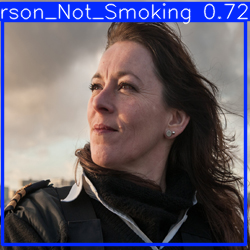

In [ ]:
import random
import cv2
import os
import torch
from google.colab.patches import cv2_imshow

# 1. Pick a random image
test_image_dir = f"{BASE_DIR}/test/images"
all_test_images = [f for f in os.listdir(test_image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
random_image = random.choice(all_test_images)
image_path = os.path.join(test_image_dir, random_image)

# 2. Run prediction (lower conf slightly to catch more potential smoking)
results = model.predict(image_path, conf=0.20)
result = results[0]

# 3. PRIORITY LOGIC: Check for any "Smoking" detection (Class 1)
# result.boxes.cls contains the class IDs: 0 = Not Smoking, 1 = Smoking
is_smoking_detected = (result.boxes.cls == 1).any()

if is_smoking_detected:
    # Filter to show ONLY Class 1 (Smoking) boxes
    indices = (result.boxes.cls == 1).nonzero().flatten()
    final_display = result[indices.tolist()]
    print(f"--- ALERT: Smoking Detected in {random_image} ---")
else:
    # Otherwise, show the Not Smoking detections
    indices = (result.boxes.cls == 0).nonzero().flatten()
    final_display = result[indices.tolist()]
    print(f"--- STATUS: Normal (Not Smoking) in {random_image} ---")

# 4. Plot and Display
res_plotted = final_display.plot()
cv2_imshow(res_plotted)